In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import scipy
import os
import re

In [ ]:
import SEACells

In [ ]:
# Some plotting aesthetics
%matplotlib inline

sns.set_style('ticks')
matplotlib.rcParams['figure.figsize'] = [4, 4]
matplotlib.rcParams['figure.dpi'] = 100

In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))

from general_utils import ismember, grep, grep_exclude, read_object, write_object
from plotting_functions import plot_individual_category


In [ ]:
def run_seacells_per_group(adata, groupby, obs_name, n_SEACells = None):
    adata_sub = adata[adata.obs[groupby] == obs_name,:].copy()

    ## Core parameters 
    if n_SEACells is None:
        n_SEACells = int(adata_sub.n_obs/75)
    build_kernel_on = 'X_pca' # key in ad.obsm to use for computing metacells    
    ## Additional parameters
    n_waypoint_eigs = 10 # Number of eigenvalues to consider when initializing metacells

    model = SEACells.core.SEACells(adata_sub, 
        build_kernel_on=build_kernel_on, 
        n_SEACells=n_SEACells, 
        n_waypoint_eigs=n_waypoint_eigs,
        convergence_epsilon = 1e-5)

    model.construct_kernel_matrix()
    M = model.kernel_matrix

    model.initialize_archetypes()
    SEACells.plot.plot_initialization(adata_sub, model)
    model.fit(min_iter=10, max_iter=100)

    SEACells.plot.plot_2D(adata_sub, key='X_umap', colour_metacells=True)
    return(adata_sub.obs['SEACell'])

### SEACells for batch m3

In [ ]:
SEACell_results = []

In [ ]:
input_path = '../preprocessed/step1_umap_annotate/Reyes_multiome_BATCH_m3_SUBSET_K2ctrl__embed.h5ad'
output_path = "../preprocessed/step3_seacells"
os.makedirs(output_path, exist_ok=True)
adata = sc.read_h5ad(input_path)

In [ ]:
adata

AnnData object with n_obs × n_vars = 6969 × 23868
    obs: 'hash_id', 'original_filename', 'folder', 'prefix', 'mouse_genotype', 'treatment', 'timepoint', 'genotype', 'dox', 'condition', 'replicate_number', 'barcode', 'unclear', 'doublet', 'batch', 'percent_mito', 'percent_ribo', 'replicate_id', 'log_lib_size_raw_all', 'log_lib_size_raw_noExcluded', 'log_detected_raw_all', 'log_detected_raw_noExcluded', 'log_lib_size_cellbender_all', 'log_lib_size_cellbender_noExcluded', 'log_detected_cellbender_all', 'log_detected_cellbender_noExcluded', 'n_counts', 'pheno_30', 'pheno_10', 'hard_threshold_stringent', 'hard_threshold_relax', 'hard_threshold', 'unclear2', 'condition_id', 'archr_valid', 'cell_type', 'DC_gastric_progenitor', 'DC_bin'
    var: 'excluded', 'n_cells', 'highly_variable'
    uns: 'cell_type_colors', 'diff_comp_eigenvalues', 'log1p', 'neighbors', 'pca', 'pca_explained_variance', 'umap'
    obsm: 'X_diff_comp', 'X_pca', 'X_umap', 'diff_operator'
    varm: 'PCs'
    layers: 'cell

In [ ]:
np.unique(adata.obs['prefix'])

array(['p489c_shRen_caer_48h_multiome_1',
       'p489c_shRen_caer_48h_multiome_2'], dtype=object)

In [ ]:
adata_sub = adata.copy()

In [ ]:
adata_sub

AnnData object with n_obs × n_vars = 6969 × 23868
    obs: 'hash_id', 'original_filename', 'folder', 'prefix', 'mouse_genotype', 'treatment', 'timepoint', 'genotype', 'dox', 'condition', 'replicate_number', 'barcode', 'unclear', 'doublet', 'batch', 'percent_mito', 'percent_ribo', 'replicate_id', 'log_lib_size_raw_all', 'log_lib_size_raw_noExcluded', 'log_detected_raw_all', 'log_detected_raw_noExcluded', 'log_lib_size_cellbender_all', 'log_lib_size_cellbender_noExcluded', 'log_detected_cellbender_all', 'log_detected_cellbender_noExcluded', 'n_counts', 'pheno_30', 'pheno_10', 'hard_threshold_stringent', 'hard_threshold_relax', 'hard_threshold', 'unclear2', 'condition_id', 'archr_valid', 'cell_type', 'DC_gastric_progenitor', 'DC_bin'
    var: 'excluded', 'n_cells', 'highly_variable'
    uns: 'cell_type_colors', 'diff_comp_eigenvalues', 'log1p', 'neighbors', 'pca', 'pca_explained_variance', 'umap'
    obsm: 'X_diff_comp', 'X_pca', 'X_umap', 'diff_operator'
    varm: 'PCs'
    layers: 'cell

Processing m3
Welcome to SEACells!
Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/6969 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/6969 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/6969 [00:00<?, ?it/s]

Constructing CSR matrix...
Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 94 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 16/16 [00:00<00:00, 121.77it/s]

Selecting 6 cells from greedy initialization.


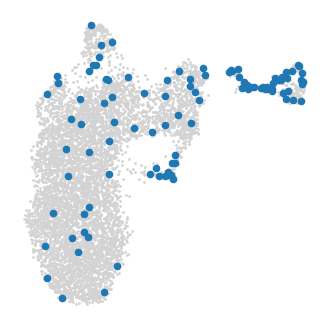

Randomly initialized A matrix.
Setting convergence threshold at 0.00155
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.
Starting iteration 30.
Completed iteration 30.
Starting iteration 40.
Completed iteration 40.
Converged after 49 iterations.


/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/site-packages/SEACells/plot.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby('SEACell').mean().reset_index()
/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


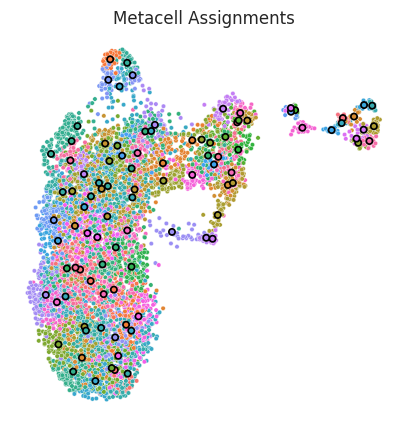

In [ ]:
unique_samples = np.unique(adata.obs['batch'])
for my_sample in unique_samples:
    print("Processing " + my_sample)
    current_result = run_seacells_per_group(adata, 'batch', my_sample, n_SEACells= 100)
    SEACell_results.append(current_result)

In [ ]:
SEACells_consolidated = pd.concat(SEACell_results)
SEACells_consolidated = SEACells_consolidated.loc[adata.obs_names].copy()
adata.obs['SEACell_original'] = SEACells_consolidated.copy()
adata.obs['SEACell_specific'] = [x + "_" + y for x,y in zip(adata.obs['batch'], adata.obs['SEACell_original'])]

In [ ]:
adata.obs['SEACell_specific']

p489c_shRen_caer_48h_multiome_1#GATAAGCCAGGTTTGC-1    m3_SEACell-72
p489c_shRen_caer_48h_multiome_1#CCAAACTAGGCCTTAG-1    m3_SEACell-51
p489c_shRen_caer_48h_multiome_1#TATCACGCATTCCTGT-1    m3_SEACell-89
p489c_shRen_caer_48h_multiome_1#GTTAGGCGTTGCTGGG-1    m3_SEACell-73
p489c_shRen_caer_48h_multiome_1#ACTCACCTCATAATCG-1    m3_SEACell-63
                                                          ...      
p489c_shRen_caer_48h_multiome_2#GCATTGCCACCTCGCT-1    m3_SEACell-53
p489c_shRen_caer_48h_multiome_2#CCTAAATCACTTAGGC-1    m3_SEACell-29
p489c_shRen_caer_48h_multiome_2#GCCAACATCAGCACGC-1    m3_SEACell-56
p489c_shRen_caer_48h_multiome_2#TTGCTCTCATCCATCT-1    m3_SEACell-22
p489c_shRen_caer_48h_multiome_2#TCTCGCCCAACTGGCT-1    m3_SEACell-51
Name: SEACell_specific, Length: 6969, dtype: object

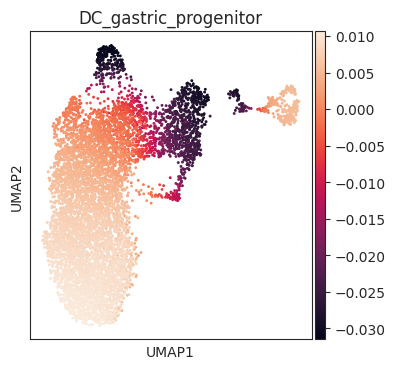

In [ ]:
sc.pl.umap(adata, color='DC_gastric_progenitor')

In [ ]:
cell_type_mode = adata.obs['cell_type'].groupby(adata.obs['SEACell_specific']).agg(lambda x: pd.Series.mode(x)[0])
sample_id_mode = adata.obs['batch'].groupby(adata.obs['SEACell_specific']).agg(lambda x: pd.Series.mode(x)[0])
DC_mean = adata.obs[['SEACell_specific', 'DC_gastric_progenitor']].groupby('SEACell_specific').agg('mean')['DC_gastric_progenitor'].to_numpy()
df = pd.DataFrame({'cell_type_mode': cell_type_mode, 'sample_id_mode': sample_id_mode, 'DC_mean': DC_mean})
df = df.sort_values(by = 'DC_mean')

df['DC_rank'] = np.argsort(df['DC_mean'], kind = 'mergesort')
df['DC_rank_formatted'] = [f"{x:03d}" for x in df['DC_rank']]
df

df['SEACell_name'] = [x + "_" + y + "_" + w + "_" + z for x,y,w,z in zip(
    df['sample_id_mode'], df['cell_type_mode'], df['DC_rank_formatted'], df.index.to_numpy())]
adata.obs['SEACell'] = df.loc[adata.obs['SEACell_specific'], 'SEACell_name'].to_numpy()

/tmp/ipykernel_801395/1086127617.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_mode = adata.obs['cell_type'].groupby(adata.obs['SEACell_specific']).agg(lambda x: pd.Series.mode(x)[0])
/tmp/ipykernel_801395/1086127617.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_id_mode = adata.obs['batch'].groupby(adata.obs['SEACell_specific']).agg(lambda x: pd.Series.mode(x)[0])
/tmp/ipykernel_801395/1086127617.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True

In [ ]:
np.sort(adata.obs['SEACell'].unique())

array(['m3_adm_000_m3_SEACell-14', 'm3_adm_001_m3_SEACell-51',
       'm3_adm_009_m3_SEACell-74', 'm3_adm_012_m3_SEACell-73',
       'm3_adm_023_m3_SEACell-64', 'm3_gastric_002_m3_SEACell-23',
       'm3_gastric_003_m3_SEACell-91', 'm3_gastric_004_m3_SEACell-39',
       'm3_gastric_007_m3_SEACell-0', 'm3_gastric_008_m3_SEACell-80',
       'm3_gastric_011_m3_SEACell-40', 'm3_gastric_013_m3_SEACell-38',
       'm3_gastric_014_m3_SEACell-99', 'm3_gastric_015_m3_SEACell-26',
       'm3_gastric_016_m3_SEACell-93', 'm3_gastric_017_m3_SEACell-7',
       'm3_gastric_018_m3_SEACell-2', 'm3_gastric_020_m3_SEACell-34',
       'm3_gastric_021_m3_SEACell-31', 'm3_gastric_022_m3_SEACell-43',
       'm3_gastric_024_m3_SEACell-16', 'm3_gastric_025_m3_SEACell-28',
       'm3_gastric_026_m3_SEACell-89', 'm3_gastric_027_m3_SEACell-81',
       'm3_gastric_028_m3_SEACell-79', 'm3_gastric_040_m3_SEACell-76',
       'm3_neuroendocrine_034_m3_SEACell-69',
       'm3_neuroendocrine_052_m3_SEACell-61',
       '

In [ ]:
output_path = re.sub("__embed.h5ad", "_SEACell.csv", input_path)
output_path = re.sub("step1_umap_annotate", "step3_seacells", output_path)
adata.obs.to_csv(output_path)

### SEACells for batch m1

In [ ]:
SEACell_results = []

In [ ]:
input_path = '../preprocessed/step1_umap_annotate/Reyes_multiome_BATCH_m1_SUBSET_K2ctrl__embed.h5ad'
output_path = "../preprocessed/step3_seacells"
os.makedirs(output_path, exist_ok=True)
adata = sc.read_h5ad(input_path)

In [ ]:
adata

AnnData object with n_obs × n_vars = 2744 × 22161
    obs: 'hash_id', 'original_filename', 'folder', 'prefix', 'mouse_genotype', 'treatment', 'timepoint', 'genotype', 'dox', 'condition', 'replicate_number', 'barcode', 'unclear', 'doublet', 'batch', 'percent_mito', 'percent_ribo', 'replicate_id', 'log_lib_size_raw_all', 'log_lib_size_raw_noExcluded', 'log_detected_raw_all', 'log_detected_raw_noExcluded', 'log_lib_size_cellbender_all', 'log_lib_size_cellbender_noExcluded', 'log_detected_cellbender_all', 'log_detected_cellbender_noExcluded', 'n_counts', 'pheno_30', 'pheno_10', 'hard_threshold_stringent', 'hard_threshold_relax', 'hard_threshold', 'unclear2', 'condition_id', 'archr_valid', 'cell_type', 'DC_gastric_progenitor', 'DC_bin'
    var: 'excluded', 'n_cells', 'highly_variable'
    uns: 'cell_type_colors', 'diff_comp_eigenvalues', 'log1p', 'neighbors', 'pca', 'pca_explained_variance', 'umap'
    obsm: 'X_diff_comp', 'X_pca', 'X_umap', 'diff_operator'
    varm: 'PCs'
    layers: 'cell

In [ ]:
np.unique(adata.obs['prefix'])

array(['DACE657_mKate2_multiome'], dtype=object)

In [ ]:
adata_sub = adata.copy()

In [ ]:
adata_sub

AnnData object with n_obs × n_vars = 2744 × 22161
    obs: 'hash_id', 'original_filename', 'folder', 'prefix', 'mouse_genotype', 'treatment', 'timepoint', 'genotype', 'dox', 'condition', 'replicate_number', 'barcode', 'unclear', 'doublet', 'batch', 'percent_mito', 'percent_ribo', 'replicate_id', 'log_lib_size_raw_all', 'log_lib_size_raw_noExcluded', 'log_detected_raw_all', 'log_detected_raw_noExcluded', 'log_lib_size_cellbender_all', 'log_lib_size_cellbender_noExcluded', 'log_detected_cellbender_all', 'log_detected_cellbender_noExcluded', 'n_counts', 'pheno_30', 'pheno_10', 'hard_threshold_stringent', 'hard_threshold_relax', 'hard_threshold', 'unclear2', 'condition_id', 'archr_valid', 'cell_type', 'DC_gastric_progenitor', 'DC_bin'
    var: 'excluded', 'n_cells', 'highly_variable'
    uns: 'cell_type_colors', 'diff_comp_eigenvalues', 'log1p', 'neighbors', 'pca', 'pca_explained_variance', 'umap'
    obsm: 'X_diff_comp', 'X_pca', 'X_umap', 'diff_operator'
    varm: 'PCs'
    layers: 'cell

Processing m1
Welcome to SEACells!
Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/2744 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/2744 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/2744 [00:00<?, ?it/s]

Constructing CSR matrix...
Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 42 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 18/18 [00:00<00:00, 530.29it/s]

Selecting 8 cells from greedy initialization.


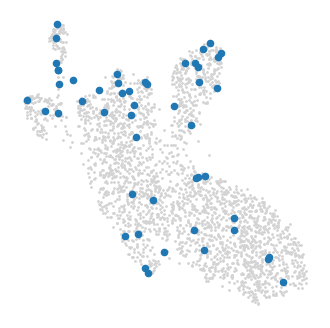

Randomly initialized A matrix.
Setting convergence threshold at 0.00092
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Starting iteration 20.
Completed iteration 20.
Converged after 23 iterations.


/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/site-packages/SEACells/plot.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby('SEACell').mean().reset_index()
/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/data1/lowes/reyesj3/miniconda3/envs/seacells/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


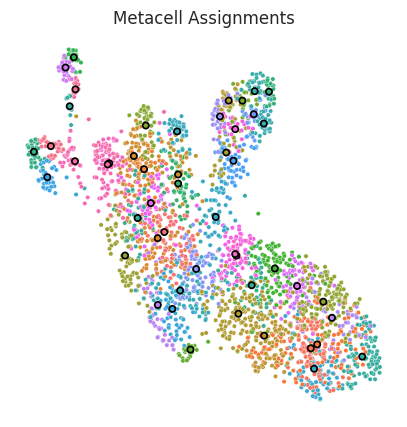

In [ ]:
unique_samples = np.unique(adata.obs['batch'])
for my_sample in unique_samples:
    print("Processing " + my_sample)
    current_result = run_seacells_per_group(adata, 'batch', my_sample, n_SEACells= 50)
    SEACell_results.append(current_result)

In [ ]:
SEACells_consolidated = pd.concat(SEACell_results)
SEACells_consolidated = SEACells_consolidated.loc[adata.obs_names].copy()
adata.obs['SEACell_original'] = SEACells_consolidated.copy()
adata.obs['SEACell_specific'] = [x + "_" + y for x,y in zip(adata.obs['batch'], adata.obs['SEACell_original'])]

In [ ]:
adata.obs['SEACell_specific']

DACE657_mKate2_multiome#CATGCAAGTTAGCTGA-1    m1_SEACell-19
DACE657_mKate2_multiome#GCCCGTTGTATTGCAG-1    m1_SEACell-36
DACE657_mKate2_multiome#TCCGGTTTCGCATTAA-1    m1_SEACell-19
DACE657_mKate2_multiome#CGGTTATAGGATAAAC-1    m1_SEACell-26
DACE657_mKate2_multiome#TTTAACGAGGACCAGG-1    m1_SEACell-15
                                                  ...      
DACE657_mKate2_multiome#GGTCTTTGTGAGGTAG-1    m1_SEACell-28
DACE657_mKate2_multiome#GATGGACAGTCATTAG-1    m1_SEACell-28
DACE657_mKate2_multiome#CGCATATAGTAATCCA-1    m1_SEACell-33
DACE657_mKate2_multiome#CACAGGGAGGACAATG-1    m1_SEACell-17
DACE657_mKate2_multiome#TGAGGCACATTGTCCT-1    m1_SEACell-39
Name: SEACell_specific, Length: 2744, dtype: object

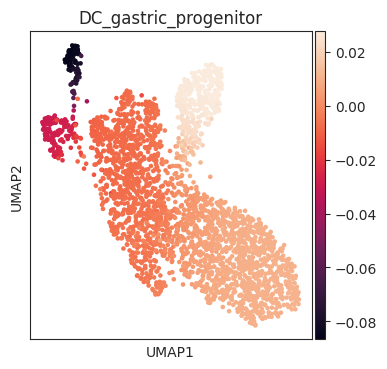

In [ ]:
sc.pl.umap(adata, color='DC_gastric_progenitor')

In [ ]:
cell_type_mode = adata.obs['cell_type'].groupby(adata.obs['SEACell_specific']).agg(lambda x: pd.Series.mode(x)[0])
sample_id_mode = adata.obs['batch'].groupby(adata.obs['SEACell_specific']).agg(lambda x: pd.Series.mode(x)[0])
DC_mean = adata.obs[['SEACell_specific', 'DC_gastric_progenitor']].groupby('SEACell_specific').agg('mean')['DC_gastric_progenitor'].to_numpy()
df = pd.DataFrame({'cell_type_mode': cell_type_mode, 'sample_id_mode': sample_id_mode, 'DC_mean': DC_mean})
df = df.sort_values(by = 'DC_mean')

df['DC_rank'] = np.argsort(df['DC_mean'], kind = 'mergesort')
df['DC_rank_formatted'] = [f"{x:03d}" for x in df['DC_rank']]
df

df['SEACell_name'] = [x + "_" + y + "_" + w + "_" + z for x,y,w,z in zip(
    df['sample_id_mode'], df['cell_type_mode'], df['DC_rank_formatted'], df.index.to_numpy())]
adata.obs['SEACell'] = df.loc[adata.obs['SEACell_specific'], 'SEACell_name'].to_numpy()

/tmp/ipykernel_801395/1086127617.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_mode = adata.obs['cell_type'].groupby(adata.obs['SEACell_specific']).agg(lambda x: pd.Series.mode(x)[0])
/tmp/ipykernel_801395/1086127617.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_id_mode = adata.obs['batch'].groupby(adata.obs['SEACell_specific']).agg(lambda x: pd.Series.mode(x)[0])
/tmp/ipykernel_801395/1086127617.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True

In [ ]:
adata.obs['SEACell']

DACE657_mKate2_multiome#CATGCAAGTTAGCTGA-1           m1_adm_040_m1_SEACell-19
DACE657_mKate2_multiome#GCCCGTTGTATTGCAG-1    m1_progenitor_028_m1_SEACell-36
DACE657_mKate2_multiome#TCCGGTTTCGCATTAA-1           m1_adm_040_m1_SEACell-19
DACE657_mKate2_multiome#CGGTTATAGGATAAAC-1       m1_gastric_020_m1_SEACell-26
DACE657_mKate2_multiome#TTTAACGAGGACCAGG-1       m1_gastric_018_m1_SEACell-15
                                                           ...               
DACE657_mKate2_multiome#GGTCTTTGTGAGGTAG-1          m1_tuft_004_m1_SEACell-28
DACE657_mKate2_multiome#GATGGACAGTCATTAG-1          m1_tuft_004_m1_SEACell-28
DACE657_mKate2_multiome#CGCATATAGTAATCCA-1           m1_adm_045_m1_SEACell-33
DACE657_mKate2_multiome#CACAGGGAGGACAATG-1           m1_adm_047_m1_SEACell-17
DACE657_mKate2_multiome#TGAGGCACATTGTCCT-1          m1_tuft_006_m1_SEACell-39
Name: SEACell, Length: 2744, dtype: object

In [ ]:
np.unique(adata.obs['SEACell'])

array(['m1_adm_040_m1_SEACell-19', 'm1_adm_041_m1_SEACell-4',
       'm1_adm_042_m1_SEACell-49', 'm1_adm_043_m1_SEACell-42',
       'm1_adm_044_m1_SEACell-32', 'm1_adm_045_m1_SEACell-33',
       'm1_adm_046_m1_SEACell-22', 'm1_adm_047_m1_SEACell-17',
       'm1_adm_048_m1_SEACell-40', 'm1_adm_049_m1_SEACell-27',
       'm1_gastric_008_m1_SEACell-8', 'm1_gastric_009_m1_SEACell-6',
       'm1_gastric_010_m1_SEACell-12', 'm1_gastric_011_m1_SEACell-14',
       'm1_gastric_012_m1_SEACell-21', 'm1_gastric_013_m1_SEACell-3',
       'm1_gastric_014_m1_SEACell-47', 'm1_gastric_015_m1_SEACell-2',
       'm1_gastric_016_m1_SEACell-35', 'm1_gastric_017_m1_SEACell-1',
       'm1_gastric_018_m1_SEACell-15', 'm1_gastric_019_m1_SEACell-13',
       'm1_gastric_020_m1_SEACell-26', 'm1_gastric_021_m1_SEACell-44',
       'm1_gastric_022_m1_SEACell-38', 'm1_gastric_023_m1_SEACell-41',
       'm1_gastric_025_m1_SEACell-23',
       'm1_neuroendocrine_000_m1_SEACell-45',
       'm1_neuroendocrine_001_m1_SEACe

In [ ]:
output_path = re.sub("__embed.h5ad", "_SEACell.csv", input_path)
output_path = re.sub("step1_umap_annotate", "step3_seacells", output_path)
adata.obs.to_csv(output_path)

### Consolidate results from both batches

In [ ]:
os.listdir("../preprocessed/step3_seacells")

['multiome_PP20251110_BATCH_m1_SUBSET_K2ctrl_SEACell.csv',
 'multiome_PP20251110_consolidated__SEACells.csv',
 'multiome_PP20251110_BATCH_m3_SUBSET_K2ctrl_SEACell.csv']

In [ ]:
selected_files = [
    'Reyes_multiome_BATCH_m1_SUBSET_K2ctrl_SEACell.csv',
    'Reyes_multiome_BATCH_m3_SUBSET_K2ctrl_SEACell.csv'
]
df = [pd.read_csv(os.path.join("../preprocessed/step3_seacells", x), index_col = 0) for x in selected_files]
df = pd.concat(df)

In [ ]:
df.to_csv(os.path.join("../preprocessed/step3_seacells", "Reyes_multiome_consolidated__SEACells.csv"))